In [4]:
import pandas as pd
import numpy as np

# Load the messy data
food = pd.read_csv("food_listings_data.csv")
providers = pd.read_csv("providers_data.csv")
receivers = pd.read_csv("receivers_data.csv")
claims = pd.read_csv("claims_data.csv")

In [15]:
providers.head()
providers.info()
providers.shape
providers.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Provider_ID  1000 non-null   int64 
 1   Name         1000 non-null   object
 2   Type         1000 non-null   object
 3   Address      1000 non-null   object
 4   City         1000 non-null   object
 5   Contact      1000 non-null   object
dtypes: int64(1), object(5)
memory usage: 47.0+ KB


Index(['Provider_ID', 'Name', 'Type', 'Address', 'City', 'Contact'], dtype='object')

In [ ]:
# Proper Column name 

In [16]:
providers.columns = providers.columns.str.strip().str.lower().str.replace(" ", "_")
receivers.columns = receivers.columns.str.strip().str.lower().str.replace(" ", "_")
food.columns = food.columns.str.strip().str.lower().str.replace(" ", "_")
claims.columns = claims.columns.str.strip().str.lower().str.replace(" ", "_")

In [20]:
print(providers.columns)
print(food.columns)
print(claims.columns)
print(receivers.columns)

Index(['provider_id', 'name', 'type', 'address', 'city', 'contact'], dtype='object')
Index(['food_id', 'food_name', 'quantity', 'expiry_date', 'provider_id',
       'provider_type', 'location', 'food_type', 'meal_type'],
      dtype='object')
Index(['claim_id', 'food_id', 'receiver_id', 'status', 'timestamp'], dtype='object')
Index(['receiver_id', 'name', 'type', 'city', 'contact'], dtype='object')


In [21]:
providers.info()
receivers.info()
food.info()
claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   provider_id  1000 non-null   int64 
 1   name         1000 non-null   object
 2   type         1000 non-null   object
 3   address      1000 non-null   object
 4   city         1000 non-null   object
 5   contact      1000 non-null   object
dtypes: int64(1), object(5)
memory usage: 47.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   receiver_id  1000 non-null   int64 
 1   name         1000 non-null   object
 2   type         1000 non-null   object
 3   city         1000 non-null   object
 4   contact      1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999


In [ ]:
#checking for nulls

In [22]:
providers.isnull().sum()

provider_id    0
name           0
type           0
address        0
city           0
contact        0
dtype: int64

In [23]:
receivers.isnull().sum()

receiver_id    0
name           0
type           0
city           0
contact        0
dtype: int64

In [24]:
food.isnull().sum()

food_id          0
food_name        0
quantity         0
expiry_date      0
provider_id      0
provider_type    0
location         0
food_type        0
meal_type        0
dtype: int64

In [25]:
claims.isnull().sum()

claim_id       0
food_id        0
receiver_id    0
status         0
timestamp      0
dtype: int64

In [ ]:
#cheking for duplicates

In [26]:
providers.duplicated().sum()
receivers.duplicated().sum()
food.duplicated().sum()
claims.duplicated().sum()

np.int64(0)

In [ ]:
#correcting datatype

In [31]:
print(food.dtypes)

food_id           int64
food_name        object
quantity          int64
expiry_date      object
provider_id       int64
provider_type    object
location         object
food_type        object
meal_type        object
dtype: object


In [32]:
food['expiry_date'] = pd.to_datetime(food['expiry_date'])

In [33]:
food.info

<bound method DataFrame.info of      food_id food_name  quantity expiry_date  provider_id     provider_type  \
0          1     Bread        43  2025-03-17          110     Grocery Store   
1          2      Soup        22  2025-03-24          791     Grocery Store   
2          3    Fruits        46  2025-03-28          478  Catering Service   
3          4    Fruits        15  2025-03-16          930        Restaurant   
4          5      Soup        14  2025-03-19          279        Restaurant   
..       ...       ...       ...         ...          ...               ...   
995      996      Fish        15  2025-03-30          467  Catering Service   
996      997      Fish        22  2025-03-18           35     Grocery Store   
997      998    Fruits         6  2025-03-22          444        Restaurant   
998      999     Pasta        15  2025-03-30          702       Supermarket   
999     1000     Salad        18  2025-03-19          155       Supermarket   

             locati

In [34]:
claims.dtypes

claim_id        int64
food_id         int64
receiver_id     int64
status         object
timestamp      object
dtype: object

In [35]:
claims['timestamp'] = pd.to_datetime(claims['timestamp'])

In [36]:
claims.info

<bound method DataFrame.info of      claim_id  food_id  receiver_id     status           timestamp
0           1      164          908    Pending 2025-03-05 05:26:00
1           2      353          391  Cancelled 2025-03-11 10:24:00
2           3      626          492  Completed 2025-03-21 00:59:00
3           4       61          933  Cancelled 2025-03-04 09:08:00
4           5      345          229    Pending 2025-03-14 15:17:00
..        ...      ...          ...        ...                 ...
995       996      855          211  Completed 2025-03-13 19:40:00
996       997      980          746  Cancelled 2025-03-17 22:04:00
997       998      832          967  Cancelled 2025-03-13 18:00:00
998       999      917           90  Completed 2025-03-01 15:31:00
999      1000      596          950  Cancelled 2025-03-13 12:51:00

[1000 rows x 5 columns]>

In [42]:
providers.dtypes

provider_id     int64
name           object
type           object
address        object
city           object
contact        object
dtype: object

In [43]:
receivers.dtypes

receiver_id     int64
name           object
type           object
city           object
contact        object
dtype: object

In [47]:
#there is no more further cleaning is required , now move to some visulizations.
import matplotlib.pyplot as plt
import seaborn as sns

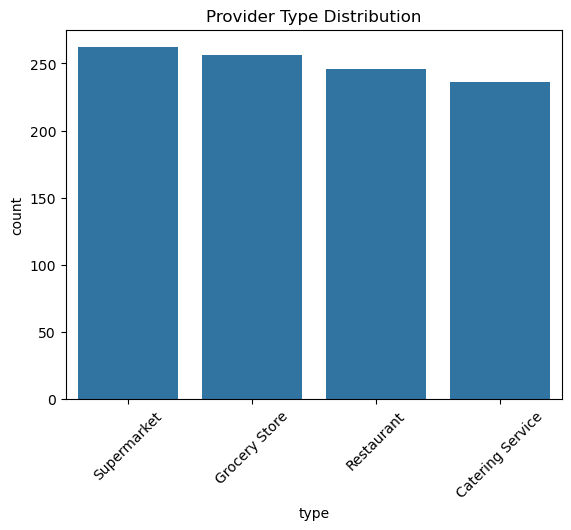

In [48]:
#Provider Type Distribution
sns.countplot(data=providers, x='type')
plt.xticks(rotation=45)
plt.title('Provider Type Distribution')
plt.show()

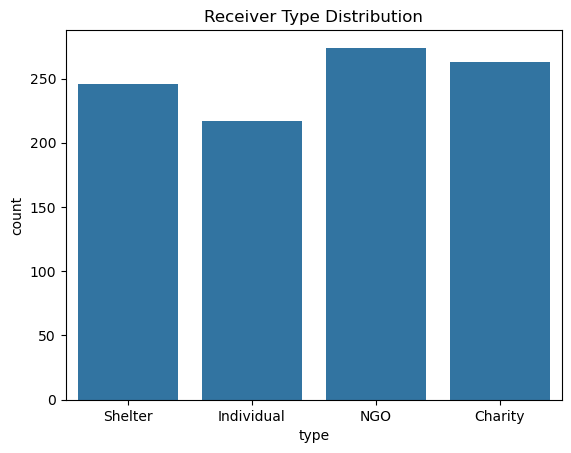

In [49]:
# 2. Receiver Type Distribution
sns.countplot(data=receivers, x='type')
plt.title('Receiver Type Distribution')
plt.show()

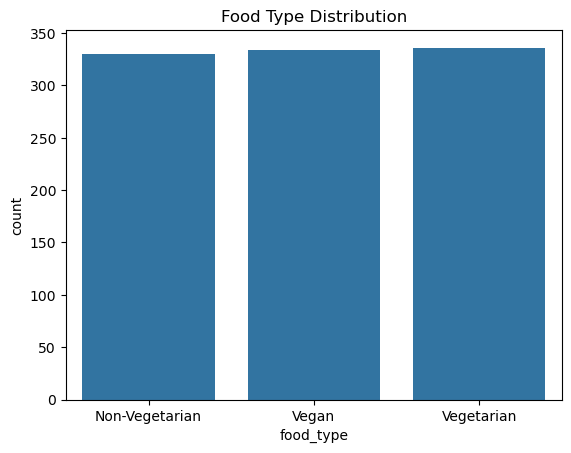

In [50]:
#3. Food Type Distribution
sns.countplot(data=food, x='food_type')
plt.title('Food Type Distribution')
plt.show()

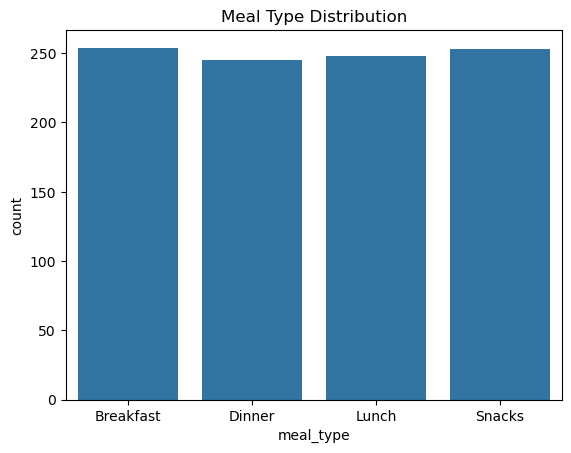

In [51]:
# 4. Meal Type Distribution
sns.countplot(data=food, x='meal_type')
plt.title('Meal Type Distribution')
plt.show()

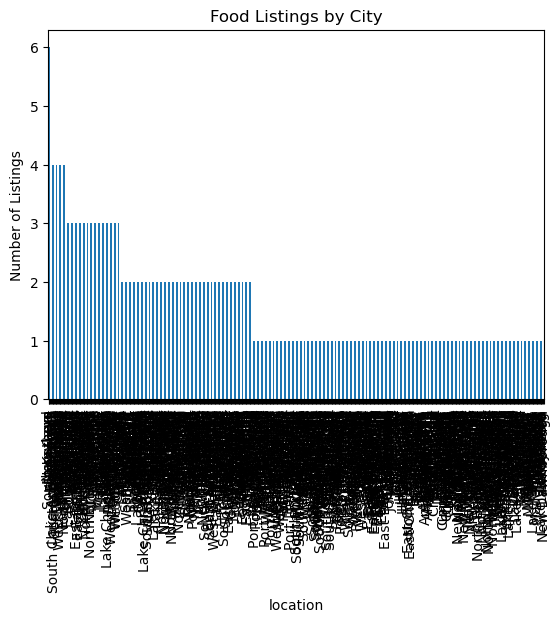

In [52]:
#5. City vs Food Listings
city_food = food.groupby('location')['food_id'].count().sort_values(ascending=False)

city_food.plot(kind='bar')
plt.title('Food Listings by City')
plt.ylabel('Number of Listings')
plt.show()

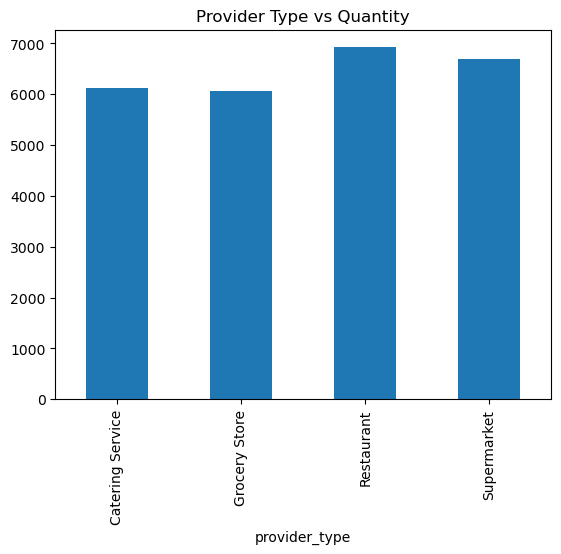

In [53]:
#6. Provider Type vs Quantity
provider_qty = food.groupby('provider_type')['quantity'].sum()

provider_qty.plot(kind='bar')
plt.title('Provider Type vs Quantity')
plt.show()

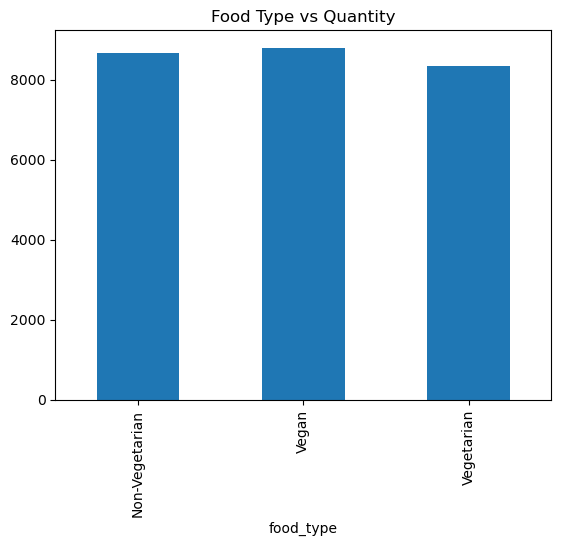

In [54]:
#7. Food Type vs Quantity
food.groupby('food_type')['quantity'].sum().plot(kind='bar')
plt.title('Food Type vs Quantity')
plt.show()

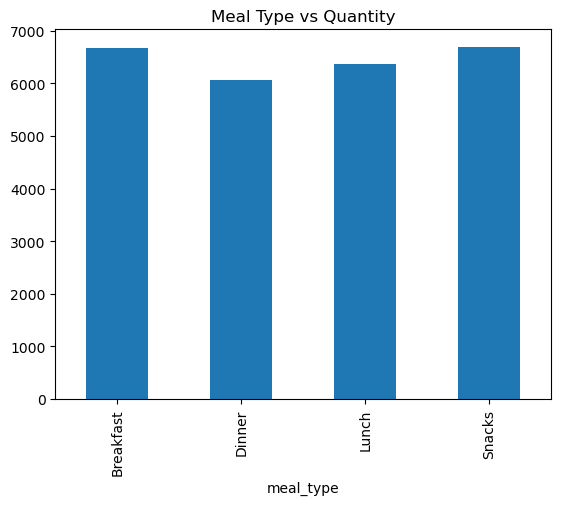

In [55]:
#8. Meal Type vs Quantity
food.groupby('meal_type')['quantity'].sum().plot(kind='bar')
plt.title('Meal Type vs Quantity')
plt.show()

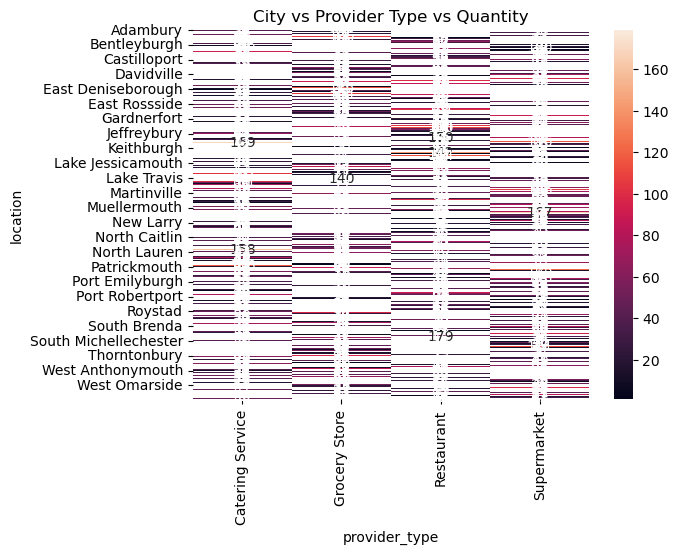

In [56]:
# 9. City + Provider Type + Quantity
pivot1 = pd.pivot_table(
    food,
    values='quantity',
    index='location',
    columns='provider_type',
    aggfunc='sum'
)

sns.heatmap(pivot1, annot=True, fmt='.0f')
plt.title('City vs Provider Type vs Quantity')
plt.show()

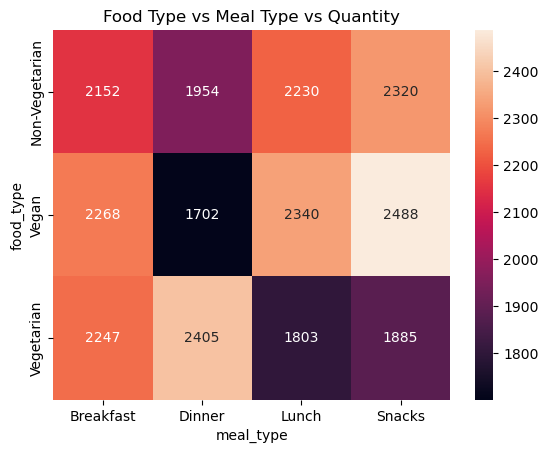

In [57]:
#10. Food Type + Meal Type + Quantity
pivot2 = pd.pivot_table(
    food,
    values='quantity',
    index='food_type',
    columns='meal_type',
    aggfunc='sum'
)

sns.heatmap(pivot2, annot=True, fmt='.0f')
plt.title('Food Type vs Meal Type vs Quantity')
plt.show()

In [58]:
#11. Provider + Claims + Quantity
food_claims = food.merge(
    claims,
    on='food_id',
    how='inner'
)

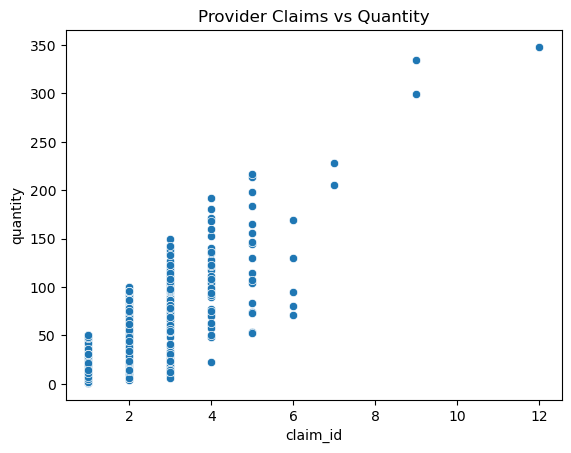

In [59]:
provider_claims = food_claims.groupby('provider_id').agg({
    'claim_id':'count',
    'quantity':'sum'
}).reset_index()

sns.scatterplot(
    data=provider_claims,
    x='claim_id',
    y='quantity'
)
plt.title('Provider Claims vs Quantity')
plt.show()

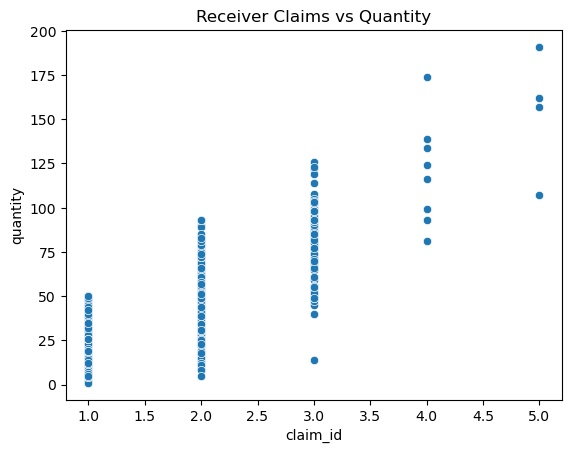

In [60]:
# 12. Receiver + Claims + Quantity
receiver_claims = food_claims.groupby('receiver_id').agg({
    'claim_id':'count',
    'quantity':'sum'
}).reset_index()

sns.scatterplot(
    data=receiver_claims,
    x='claim_id',
    y='quantity'
)
plt.title('Receiver Claims vs Quantity')
plt.show()

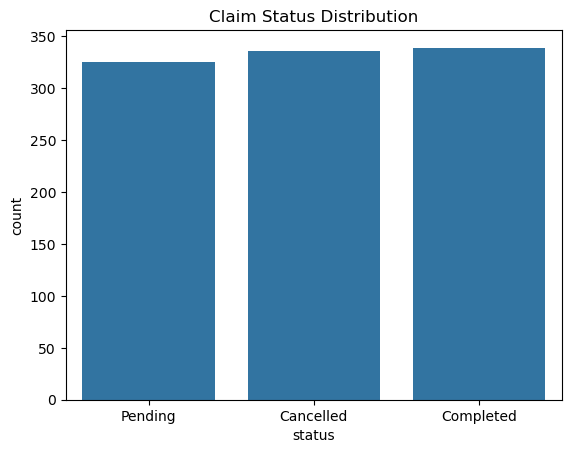

In [61]:
#13. Claim Status Distribution
sns.countplot(data=claims, x='status')
plt.title('Claim Status Distribution')
plt.show()

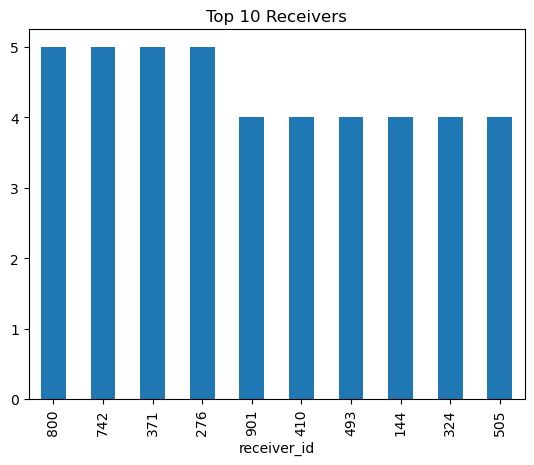

In [62]:
# 14. Top 10 Receivers
top_receivers = claims['receiver_id'].value_counts().head(10)

top_receivers.plot(kind='bar')
plt.title('Top 10 Receivers')
plt.show()

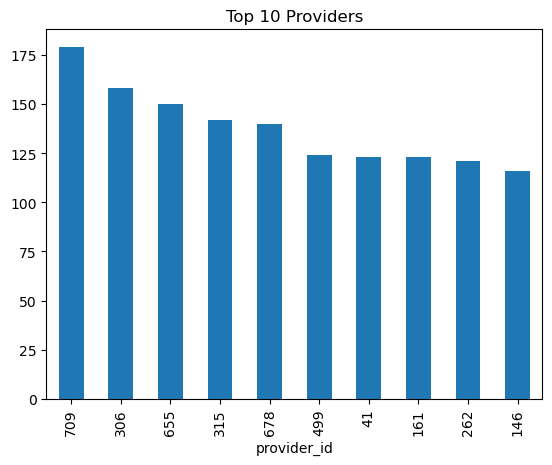

In [64]:
#15. Top 10 Providers
top_providers = food.groupby('provider_id')['quantity'].sum().nlargest(10)

top_providers.plot(kind='bar')
plt.title('Top 10 Providers')
plt.show()

In [66]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# SQL Server Details
server = r"DESKTOP-BDSN4BM\SQLEXPRESS"
database = "local_food_management"

# Driver
driver = quote_plus("ODBC Driver 17 for SQL Server")

# Connection
engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes"
)

# Upload Tables
providers.to_sql(
    "providers",
    engine,
    if_exists="replace",
    index=False,
    chunksize=500
)

receivers.to_sql(
    "receivers",
    engine,
    if_exists="replace",
    index=False,
    chunksize=500
)

food.to_sql(
    "food_listings",
    engine,
    if_exists="replace",
    index=False,
    chunksize=500
)

claims.to_sql(
    "claims",
    engine,
    if_exists="replace",
    index=False,
    chunksize=500
)

print("✅ All tables uploaded successfully")

E:\anaconda\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


✅ All tables uploaded successfully


In [68]:
pd.read_sql("SELECT COUNT(*) AS total_rows FROM providers", engine)

,total_rows
0,1000
